# Part 3: Spark Data Processing
### Banking Dataset - All 12 Questions
> PySpark runs inside Google Colab via the `pyspark` pip package.

### Github : xxxxx

In [ ]:
!pip install pyspark matplotlib seaborn pandas -q
print('PySpark installed properly ✓')

PySpark installed properly ✓


In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import StringType
import matplotlib.pyplot as plt, pandas as pd

spark = SparkSession.builder.appName('BankingSparkProcessing').master('local[*]').getOrCreate()
spark.sparkContext.setLogLevel('ERROR')
print('Spark version:', spark.version)

Spark version: 4.0.2


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
df = spark.read.csv('/content/drive/MyDrive/Colab Notebooks/SPECIALIZATION MS PROJECTS/MODULE 2/bank.csv', header=True, inferSchema=True)
print(f'Rows: {df.count()}  Columns: {len(df.columns)}')

Mounted at /content/drive
Rows: 4521  Columns: 17


## Q1 – Data Loading and Basic Inspection

In [ ]:
# Display sample records
df.show(5)

# Print DataFrame schema
df.printSchema()

# Generate summary statistics for selected numerical columns
df.select(
    'age',
    'balance',
    'duration',
    'campaign',
    'pdays',
    'previous'
).describe().show()

+---+-----------+-------+---------+-------+-------+-------+----+--------+---+-----+--------+--------+-----+--------+--------+---+
|age|        job|marital|education|default|balance|housing|loan| contact|day|month|duration|campaign|pdays|previous|poutcome|  y|
+---+-----------+-------+---------+-------+-------+-------+----+--------+---+-----+--------+--------+-----+--------+--------+---+
| 30| unemployed|married|  primary|     no|   1787|     no|  no|cellular| 19|  oct|      79|       1|   -1|       0| unknown| no|
| 33|   services|married|secondary|     no|   4789|    yes| yes|cellular| 11|  may|     220|       1|  339|       4| failure| no|
| 35| management| single| tertiary|     no|   1350|    yes|  no|cellular| 16|  apr|     185|       1|  330|       1| failure| no|
| 30| management|married| tertiary|     no|   1476|    yes| yes| unknown|  3|  jun|     199|       4|   -1|       0| unknown| no|
| 59|blue-collar|married|secondary|     no|      0|    yes|  no| unknown|  5|  may|     22

## Q2 – Data Filtering and Column Operations

In [ ]:
# Filter records where balance exceeds 1000
filtered_df = df.filter(F.col('balance') > 1000)

# Count matching clients
print(f'Clients with balance > 1000: {filtered_df.count()}')

# Display a sample of filtered results
filtered_df.show(5)

Clients with balance > 1000: 1481
+---+----------+-------+---------+-------+-------+-------+----+--------+---+-----+--------+--------+-----+--------+--------+---+
|age|       job|marital|education|default|balance|housing|loan| contact|day|month|duration|campaign|pdays|previous|poutcome|  y|
+---+----------+-------+---------+-------+-------+-------+----+--------+---+-----+--------+--------+-----+--------+--------+---+
| 30|unemployed|married|  primary|     no|   1787|     no|  no|cellular| 19|  oct|      79|       1|   -1|       0| unknown| no|
| 33|  services|married|secondary|     no|   4789|    yes| yes|cellular| 11|  may|     220|       1|  339|       4| failure| no|
| 35|management| single| tertiary|     no|   1350|    yes|  no|cellular| 16|  apr|     185|       1|  330|       1| failure| no|
| 30|management|married| tertiary|     no|   1476|    yes| yes| unknown|  3|  jun|     199|       4|   -1|       0| unknown| no|
| 39|  services|married|secondary|     no|   9374|    yes|  no|

In [ ]:
# Create a mapping of months to quarters
quarter_mapping = F.create_map(
    F.lit('jan'), F.lit('Q1'), F.lit('feb'), F.lit('Q1'), F.lit('mar'), F.lit('Q1'),
    F.lit('apr'), F.lit('Q2'), F.lit('may'), F.lit('Q2'), F.lit('jun'), F.lit('Q2'),
    F.lit('jul'), F.lit('Q3'), F.lit('aug'), F.lit('Q3'), F.lit('sep'), F.lit('Q3'),
    F.lit('oct'), F.lit('Q4'), F.lit('nov'), F.lit('Q4'), F.lit('dec'), F.lit('Q4')
)

# Add a new column 'quarter' based on the month
df = df.withColumn('quarter', quarter_mapping[F.col('month')])

# Display distinct month-quarter pairs
df.select('month', 'quarter').distinct().orderBy('month').show()

+-----+-------+
|month|quarter|
+-----+-------+
|  apr|     Q2|
|  aug|     Q3|
|  dec|     Q4|
|  feb|     Q1|
|  jan|     Q1|
|  jul|     Q3|
|  jun|     Q2|
|  mar|     Q1|
|  may|     Q2|
|  nov|     Q4|
|  oct|     Q4|
|  sep|     Q3|
+-----+-------+



## Q3 – GroupBy and Aggregation

In [ ]:
# Avg balance and median age per job
df.groupBy('job').agg(
    F.round(F.avg('balance'),2).alias('avg_balance'),
    F.percentile_approx('age',0.5).alias('median_age'),
    F.count('*').alias('count')
).orderBy(F.desc('avg_balance')).show()

+-------------+-----------+----------+-----+
|          job|avg_balance|median_age|count|
+-------------+-----------+----------+-----+
|      retired|    2319.19|        59|  230|
|    housemaid|     2083.8|        49|  112|
|   management|    1766.93|        38|  969|
| entrepreneur|    1645.13|        41|  168|
|      student|    1543.82|        26|   84|
|      unknown|    1501.71|        49|   38|
|self-employed|    1392.41|        40|  183|
|   technician|     1331.0|        38|  768|
|       admin.|    1226.74|        38|  478|
|     services|    1103.96|        37|  417|
|   unemployed|    1089.42|        41|  128|
|  blue-collar|    1085.16|        39|  946|
+-------------+-----------+----------+-----+



In [ ]:
# Subscribed clients per marital status
df.filter(F.col('y')=='yes').groupBy('marital').count().orderBy(F.desc('count')).show()

+--------+-----+
| marital|count|
+--------+-----+
| married|  277|
|  single|  167|
|divorced|   77|
+--------+-----+



## Q4 – UDF to Categorize Age Groups

In [ ]:
# Define UDF to categorize age into groups
@F.udf(StringType())
def categorize_age(age):
    if age is None:
        return 'unknown'
    elif age < 30:
        return '<30'
    elif age <= 60:
        return '30-60'
    else:
        return '>60'

# Add new column 'age_group'
df = df.withColumn('age_group', categorize_age(F.col('age')))

# Count records in each age group
df.groupBy('age_group').count().orderBy('age_group').show()

print('age_group column successfully added with categories: <30, 30-60, >60')

+---------+-----+
|age_group|count|
+---------+-----+
|    30-60| 3912|
|      <30|  482|
|      >60|  127|
+---------+-----+

age_group column successfully added with categories: <30, 30-60, >60


## Q5 – Advanced Data Transformations

In [ ]:
# Subscription rate by education
df.groupBy('education').agg(
    F.count('*').alias('total'),
    F.sum(F.when(F.col('y')=='yes',1).otherwise(0)).alias('subscribed')
).withColumn('sub_rate_%', F.round(F.col('subscribed')*100.0/F.col('total'),2)
).orderBy(F.desc('sub_rate_%')).show()

+---------+-----+----------+----------+
|education|total|subscribed|sub_rate_%|
+---------+-----+----------+----------+
| tertiary| 1350|       193|      14.3|
|secondary| 2306|       245|     10.62|
|  unknown|  187|        19|     10.16|
|  primary|  678|        64|      9.44|
+---------+-----+----------+----------+



In [ ]:
# Top 3 professions by loan default rate
df.groupBy('job').agg(
    F.count('*').alias('total'),
    F.sum(F.when(F.col('default')=='yes',1).otherwise(0)).alias('defaults')
).withColumn('default_rate_%',F.round(F.col('defaults')*100.0/F.col('total'),2)
).orderBy(F.desc('default_rate_%')).limit(3).show()

+-------------+-----+--------+--------------+
|          job|total|defaults|default_rate_%|
+-------------+-----+--------+--------------+
| entrepreneur|  168|       7|          4.17|
|   unemployed|  128|       3|          2.34|
|self-employed|  183|       4|          2.19|
+-------------+-----+--------+--------------+



## Q6 – String Manipulation

In [ ]:
df = df.withColumn('job_marital', F.concat_ws('_', 'job','marital'))
df = df.withColumn('contact_upper', F.upper('contact'))
df.select('job','marital','job_marital','contact','contact_upper').show(5)

+-----------+-------+-------------------+--------+-------------+
|        job|marital|        job_marital| contact|contact_upper|
+-----------+-------+-------------------+--------+-------------+
| unemployed|married| unemployed_married|cellular|     CELLULAR|
|   services|married|   services_married|cellular|     CELLULAR|
| management| single|  management_single|cellular|     CELLULAR|
| management|married| management_married| unknown|      UNKNOWN|
|blue-collar|married|blue-collar_married| unknown|      UNKNOWN|
+-----------+-------+-------------------+--------+-------------+
only showing top 5 rows


## Q7 – Data Visualization

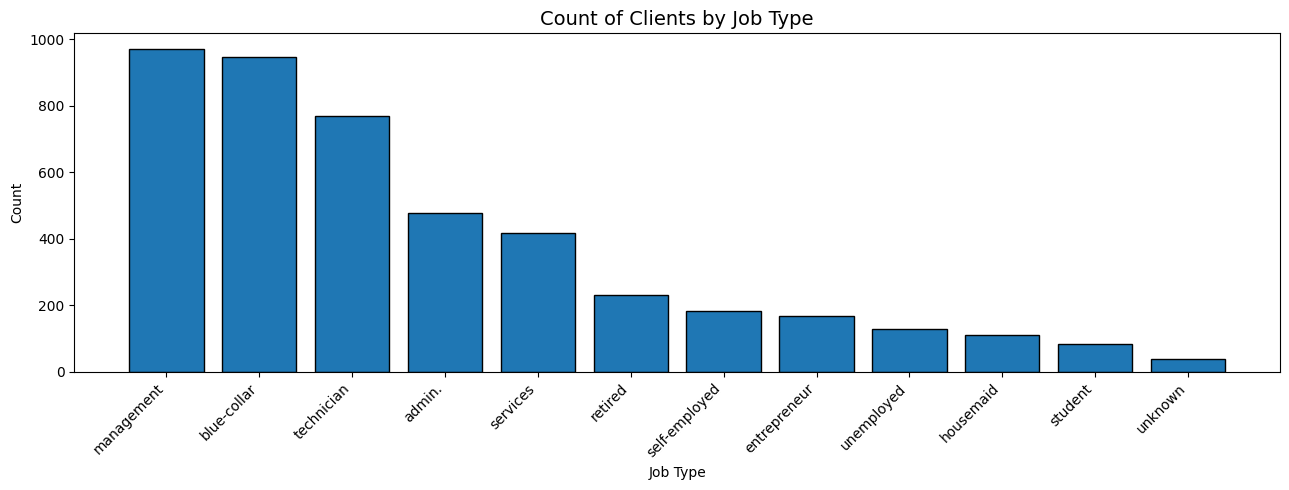

In [ ]:
# Convert Spark DataFrame to Pandas for visualization
job_counts_df = (
    df.groupBy('job')
      .count()
      .orderBy(F.desc('count'))
      .toPandas()
)

# Plot client distribution by job type
plt.figure(figsize=(13, 5))
plt.bar(
    job_counts_df['job'],
    job_counts_df['count'],
    edgecolor='black'
)

plt.xticks(rotation=45, ha='right')
plt.title('Count of Clients by Job Type', fontsize=14)
plt.xlabel('Job Type')
plt.ylabel('Count')

plt.tight_layout()
plt.savefig('spark_clients_by_job.png', dpi=150)
plt.show()

## Q8 – Complex Queries for Insights

In [ ]:
# Month with highest contacts + success rate
df.groupBy('month').agg(
    F.count('*').alias('contacts'),
    F.round(F.sum(F.when(F.col('y')=='yes',1).otherwise(0))*100.0/F.count('*'),2).alias('success_%')
).orderBy(F.desc('contacts')).show(5)

# Avg duration: subscribed vs not
df.groupBy('y').agg(F.round(F.avg('duration'),2).alias('avg_duration_sec')).show()

+-----+--------+---------+
|month|contacts|success_%|
+-----+--------+---------+
|  may|    1398|     6.65|
|  jul|     706|     8.64|
|  aug|     633|    12.48|
|  jun|     531|    10.36|
|  nov|     389|    10.03|
+-----+--------+---------+
only showing top 5 rows
+---+----------------+
|  y|avg_duration_sec|
+---+----------------+
| no|          226.35|
|yes|          552.74|
+---+----------------+



## Q9 – Correlation Between Age and Balance

In [ ]:
corr = df.stat.corr('age','balance')
print(f'Pearson correlation (age vs balance): {corr:.4f}')
print('A value near 0 indicates no strong linear relationship.')

Pearson correlation (age vs balance): 0.0838
A value near 0 indicates no strong linear relationship.


## Q10 – Exploring Loan Defaults

  default  count
0      no   4445
1     yes     76


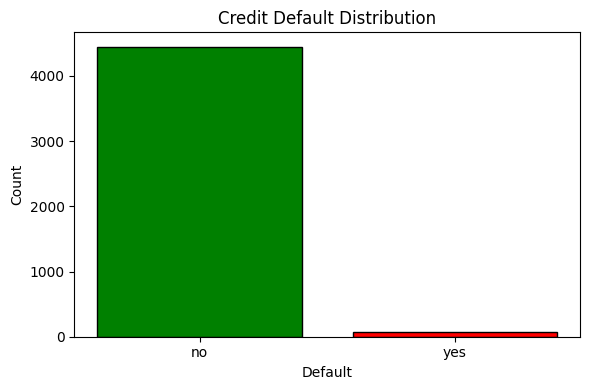

In [ ]:
default_counts = df.groupBy('default').count().toPandas()
print(default_counts)
plt.figure(figsize=(6,4))
plt.bar(default_counts['default'], default_counts['count'], color=['green','red'], edgecolor='black')
plt.title('Credit Default Distribution'); plt.xlabel('Default'); plt.ylabel('Count')
plt.tight_layout(); plt.savefig('spark_default_dist.png',dpi=150); plt.show()

## Q11 – Contact Method Analysis

In [ ]:
df.groupBy('contact').agg(
    F.count('*').alias('total'),
    F.sum(F.when(F.col('y')=='yes',1).otherwise(0)).alias('subscribed'),
    F.round(F.sum(F.when(F.col('y')=='yes',1.0).otherwise(0))*100/F.count('*'),2).alias('success_%')
).orderBy(F.desc('success_%')).show()

+---------+-----+----------+---------+
|  contact|total|subscribed|success_%|
+---------+-----+----------+---------+
|telephone|  301|        44|    14.62|
| cellular| 2896|       416|    14.36|
|  unknown| 1324|        61|     4.61|
+---------+-----+----------+---------+



## Q12 – Spark SQL with Temporary View

In [ ]:
df.createOrReplaceTempView('bank_view')
# Avg balance by age group
spark.sql("""
    SELECT age_group,
           ROUND(AVG(balance),2) AS avg_balance,
           COUNT(*) AS client_count
    FROM bank_view
    GROUP BY age_group
    ORDER BY age_group
""").show()

# Most common job types
spark.sql("""
    SELECT job, COUNT(*) AS count
    FROM bank_view
    GROUP BY job
    ORDER BY count DESC
    LIMIT 5
""").show()

+---------+-----------+------------+
|age_group|avg_balance|client_count|
+---------+-----------+------------+
|    30-60|    1426.88|        3912|
|      <30|     1058.1|         482|
|      >60|    2676.35|         127|
+---------+-----------+------------+

+-----------+-----+
|        job|count|
+-----------+-----+
| management|  969|
|blue-collar|  946|
| technician|  768|
|     admin.|  478|
|   services|  417|
+-----------+-----+



In [ ]:
spark.stop()
print('All 12 Spark Processing questions complete ✓')

All 12 Spark Processing questions complete ✓
